<a href="https://colab.research.google.com/github/Fergit42/Fergit42/blob/main/SeriesTiempo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<ipython-input-1-074fb039400f>:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time = pd.date_range(start='2018-01-01', periods=n_periods, freq='M')  # Fechas mensuales


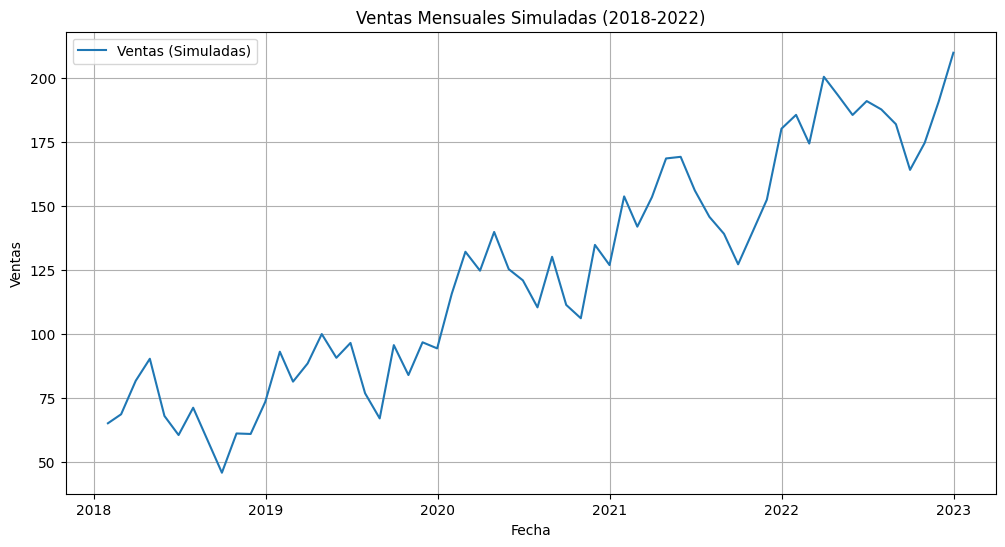

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


Error cuadrático medio (MSE): 252.21


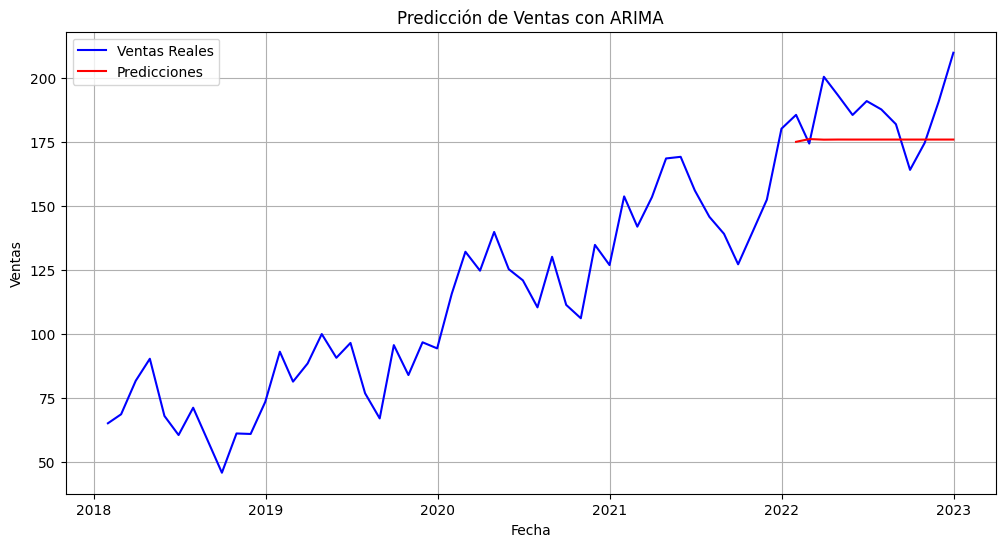

In [ ]:
# Importar las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# Simular datos de series temporales: Ventas mensuales durante 5 años
np.random.seed(42)
n_periods = 60  # 5 años de datos mensuales
time = pd.date_range(start='2018-01-01', periods=n_periods, freq='M')  # Fechas mensuales
trend = np.linspace(50, 200, n_periods)  # Tendencia creciente
seasonality = 20 * np.sin(2 * np.pi * time.month / 12)  # Componente estacional
noise = np.random.normal(0, 10, n_periods)  # Ruido aleatorio
sales = trend + seasonality + noise  # Serie temporal de ventas

# Crear un DataFrame con los datos simulados
data = pd.DataFrame({'Date': time, 'Sales': sales})
data.set_index('Date', inplace=True)

# Visualización de la serie temporal
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Sales'], label='Ventas (Simuladas)')
plt.title('Ventas Mensuales Simuladas (2018-2022)')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid()
plt.show()

# Dividir los datos en conjunto de entrenamiento y prueba
train_size = int(len(data) * 0.8)
train, test = data.iloc[:train_size], data.iloc[train_size:]

# Ajustar un modelo ARIMA para predicción
# ARIMA(p, d, q): p = términos autorregresivos, d = diferenciación, q = términos de media móvil
model = ARIMA(train['Sales'], order=(1, 1, 1))  # Modelo ARIMA con parámetros iniciales
model_fit = model.fit()

# Predicción en el conjunto de prueba
forecast = model_fit.forecast(steps=len(test))

# Evaluar el modelo
mse = mean_squared_error(test['Sales'], forecast)
print(f"Error cuadrático medio (MSE): {mse:.2f}")

# Visualización de las predicciones
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Sales'], label='Ventas Reales', color='blue')
plt.plot(test.index, forecast, label='Predicciones', color='red')
plt.title('Predicción de Ventas con ARIMA')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid()
plt.show()

